In [63]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r"C:\Users\asgaj\Downloads\youtube recommendation dataset.csv"
)

In [3]:
df.shape

(1000000, 14)

In [4]:
df.head()

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
0,88263,19387,1499,1499.0,1,0,0,News,TV,Night,0,0,2025-07-16 06:10:54,1.000000
1,46796,5150,2955,2955.0,1,0,0,Education,Mobile,Night,1,1,2024-07-09 10:22:22,1.000000
2,77686,3172,389,389.0,0,0,0,Sports,Desktop,Afternoon,0,0,2025-02-07 09:46:36,1.000000
3,26723,27669,1231,1231.0,1,1,0,Gaming,TV,Evening,0,0,2024-04-28 08:07:13,1.000000
4,55299,24612,3573,353.0,0,1,0,Lifestyle,Desktop,Evening,1,0,2024-03-30 12:54:24,0.098797


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   user_id            1000000 non-null  int64  
 1   video_id           1000000 non-null  int64  
 2   video_duration     1000000 non-null  int64  
 3   watch_time         1000000 non-null  float64
 4   liked              997952 non-null   str    
 5   commented          1000000 non-null  int64  
 6   subscribed_after   1000000 non-null  int64  
 7   category           1000000 non-null  str    
 8   device             1000000 non-null  str    
 9   watch_time_of_day  1000000 non-null  str    
 10  recommended        1000000 non-null  int64  
 11  clicked            1000000 non-null  int64  
 12  timestamp          1000000 non-null  str    
 13  watch_percent      1000000 non-null  float64
dtypes: float64(2), int64(7), str(5)
memory usage: 143.5 MB


In [6]:
# Check missing values in each column
df.isna().sum()

user_id                 0
video_id                0
video_duration          0
watch_time              0
liked                2048
commented               0
subscribed_after        0
category                0
device                  0
watch_time_of_day       0
recommended             0
clicked                 0
timestamp               0
watch_percent           0
dtype: int64

In [7]:
df["liked"].value_counts(dropna=False)

liked
0      696155
1      298845
NaN      2048
2        1007
no        988
yes       957
Name: count, dtype: int64

In [8]:
# Check unique values in categorical columns

for col in ["category", "device", "watch_time_of_day"]:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 category
category
Comedy       124467
News         123920
Music        123851
Tech         123735
Sports       123644
Gaming       123595
Lifestyle    123457
Education    123331
Tech           1749
gamingg        1734
MUsic          1663
Ed             1637
music          1629
COMEDY         1588
Name: count, dtype: int64

 device
device
TV         250083
Tablet     250066
Desktop    249983
Mobile     249868
Name: count, dtype: int64

 watch_time_of_day
watch_time_of_day
Morning      250258
Afternoon    250246
Evening      249822
Night        249674
Name: count, dtype: int64


In [9]:
# Check numerical columns
df.describe()

C:\Users\asgaj\anaconda3\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,user_id,video_id,video_duration,watch_time,commented,subscribed_after,recommended,clicked,watch_percent
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,50014.595087,25008.932584,1911.577131,1283.683469,0.099497,0.050004,0.399768,0.300771,inf
std,28864.277887,14434.546717,3270.284893,2499.074293,0.299328,0.217953,0.489851,0.458594,NaN
min,1.000000,1.000000,0.000000,-299.000000,0.000000,0.000000,0.000000,0.000000,-2.990000e-03
25%,24998.000000,12503.000000,921.000000,498.000000,0.000000,0.000000,0.000000,0.000000,4.990537e-01
50%,50048.000000,25020.000000,1816.000000,1071.000000,0.000000,0.000000,0.000000,0.000000,9.963570e-01
75%,75022.000000,37522.000000,2710.000000,1821.000000,0.000000,0.000000,1.000000,1.000000,1.000000e+00
max,100000.000000,50000.000000,100000.000000,109969.000000,1.000000,1.000000,1.000000,1.000000,inf


In [10]:
# Check suspicious numerical values

print("Negative watch_time:", (df["watch_time"] < 0).sum())
print("Zero video_duration:", (df["video_duration"] == 0).sum())
print("Watch time > video duration:", (df["watch_time"] > df["video_duration"]).sum())
print("Invalid watch_percent:", (
    (df["watch_percent"] < 0) |
    (df["watch_percent"] > 1) |
    (~df["watch_percent"].between(0, 1))
).sum())
print("Infinite watch_percent:", df["watch_percent"].isin([float("inf"), float("-inf")]).sum())

Negative watch_time: 500
Zero video_duration: 1000
Watch time > video duration: 4500
Invalid watch_percent: 5000
Infinite watch_percent: 1000


In [61]:
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print("Missing:", df["timestamp"].isna().sum())
print("Min:", df["timestamp"].min())
print("Max:", df["timestamp"].max())

Missing: 2000
Min: 2023-01-01 00:01:33
Max: 2025-09-29 23:53:31


In [34]:
# Inspect invalid timestamps
df[df["timestamp"].isna()].head(10)

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
177,25238,4381,0,1213.0,no,0,0,MUsic,Desktop,Afternoon,1,0,NaT,inf
241,73786,2261,0,943.0,no,0,0,MUsic,Desktop,Night,0,0,NaT,inf
482,39486,2977,100000,107238.0,no,0,0,Ed,Mobile,Afternoon,1,0,NaT,1.07238
641,80857,41009,0,5549.0,yes,0,0,music,Mobile,Night,0,0,NaT,inf
859,84560,6188,100000,-52.0,NaN,1,0,Ed,TV,Night,0,1,NaT,-0.00052
1444,14426,13154,0,6633.0,NaN,0,0,COMEDY,Tablet,Evening,1,1,NaT,inf
1991,15228,3668,100000,-151.0,2,0,0,Ed,TV,Evening,0,0,NaT,-0.00151
3084,7060,10372,0,1392.0,no,0,0,MUsic,Tablet,Evening,1,0,NaT,inf
3187,92507,38288,0,5818.0,yes,0,0,gamingg,Mobile,Evening,1,0,NaT,inf
3649,56628,47657,0,6476.0,2,0,0,Tech,Desktop,Morning,1,0,NaT,inf


In [35]:
# Check timestamp cleaning
print("Missing timestamps:", df["timestamp"].isna().sum())
print("Valid timestamps:", df["timestamp"].notna().sum())

Missing timestamps: 2000
Valid timestamps: 998000


In [36]:
# Clean liked values
df["liked"] = df["liked"].replace({
    "yes": 1,
    "no": 0,
    2: pd.NA,
    "2": pd.NA
})

df["liked"] = pd.to_numeric(df["liked"], errors="coerce")

# Check result
df["liked"].value_counts(dropna=False)

liked
0.0    697143
1.0    299802
NaN      3055
Name: count, dtype: int64

In [37]:
# Standardize category names
df["category"] = df["category"].str.strip().str.title()

df["category"].value_counts()

category
Music        127143
Comedy       126055
Tech         125484
News         123920
Sports       123644
Gaming       123595
Lifestyle    123457
Education    123331
Gamingg        1734
Ed             1637
Name: count, dtype: int64

In [38]:
# Fix remaining category labels
df["category"] = df["category"].replace({
    "Gamingg": "Gaming",
    "Ed": "Education"
})

# Verify
df["category"].value_counts()

category
Music        127143
Comedy       126055
Tech         125484
Gaming       125329
Education    124968
News         123920
Sports       123644
Lifestyle    123457
Name: count, dtype: int64

In [39]:
# Check binary columns
for col in ["commented", "subscribed_after", "recommended", "clicked"]:
    print(col, df[col].unique())

commented [0 1]
subscribed_after [0 1]
recommended [0 1]
clicked [0 1]


In [41]:
# Fix impossible watch times
df.loc[df["watch_time"] < 0, "watch_time"] = 0

mask = df["watch_time"] > df["video_duration"]
df.loc[mask, "watch_time"] = df.loc[mask, "video_duration"]

# Verify
print("Negative:", (df["watch_time"] < 0).sum())
print("Greater than duration:", (df["watch_time"] > df["video_duration"]).sum())

Negative: 0
Greater than duration: 0


In [43]:
# Handle zero-duration videos
df.loc[df["video_duration"] == 0, "watch_percent"] = pd.NA

# Verify
print("Missing watch_percent:", df["watch_percent"].isna().sum())

Missing watch_percent: 1000


In [44]:
# Recalculate watch percentage
mask = df["video_duration"] > 0

df.loc[mask, "watch_percent"] = (
    df.loc[mask, "watch_time"] / df.loc[mask, "video_duration"]
)

# Verify
print("Missing:", df["watch_percent"].isna().sum())
print("Below 0:", (df["watch_percent"] < 0).sum())
print("Above 1:", (df["watch_percent"] > 1).sum())

Missing: 1000
Below 0: 0
Above 1: 0


In [46]:
# Check final data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   user_id            1000000 non-null  int64         
 1   video_id           1000000 non-null  int64         
 2   video_duration     1000000 non-null  int64         
 3   watch_time         1000000 non-null  float64       
 4   liked              996945 non-null   float64       
 5   commented          1000000 non-null  int64         
 6   subscribed_after   1000000 non-null  int64         
 7   category           1000000 non-null  str           
 8   device             1000000 non-null  str           
 9   watch_time_of_day  1000000 non-null  str           
 10  recommended        1000000 non-null  int64         
 11  clicked            1000000 non-null  int64         
 12  timestamp          998000 non-null   datetime64[us]
 13  watch_percent      999000 non-null   fl

In [47]:
# Final data quality check
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values:")
print(df.isna().sum())

Rows: 1000000
Columns: 14
Missing values:
user_id                 0
video_id                0
video_duration          0
watch_time              0
liked                3055
commented               0
subscribed_after        0
category                0
device                  0
watch_time_of_day       0
recommended             0
clicked                 0
timestamp            2000
watch_percent        1000
dtype: int64


In [48]:
# Overall engagement metrics
print("Total interactions:", len(df))
print("Unique users:", df["user_id"].nunique())
print("Unique videos:", df["video_id"].nunique())
print("Average watch %:", round(df["watch_percent"].mean() * 100, 2))
print("Like rate:", round(df["liked"].mean() * 100, 2))
print("Comment rate:", round(df["commented"].mean() * 100, 2))
print("Click rate:", round(df["clicked"].mean() * 100, 2))
print("Recommendation rate:", round(df["recommended"].mean() * 100, 2))
print("Subscription rate:", round(df["subscribed_after"].mean() * 100, 2))

Total interactions: 1000000
Unique users: 99990
Unique videos: 50000
Average watch %: 74.93
Like rate: 30.07
Comment rate: 9.95
Click rate: 30.08
Recommendation rate: 39.98
Subscription rate: 5.0


In [59]:
# Create balanced video-length groups
df["duration_group"] = pd.qcut(
    df["video_duration"],
    q=4,
    labels=["Shorter", "Moderate", "Long", "Very Long"],
    duplicates="drop"
)

duration_analysis = df.groupby("duration_group", observed=True).agg(
    interactions=("video_id", "count"),
    avg_watch_percent=("watch_percent", "mean"),
    like_rate=("liked", "mean"),
    comment_rate=("commented", "mean")
).reset_index()

duration_analysis

,duration_group,interactions,avg_watch_percent,like_rate,comment_rate
0,Shorter,250244,0.934858,0.301192,0.099323
1,Moderate,250006,0.810843,0.300844,0.099062
2,Long,249824,0.688355,0.300611,0.099498
3,Very Long,249926,0.563625,0.300235,0.100106


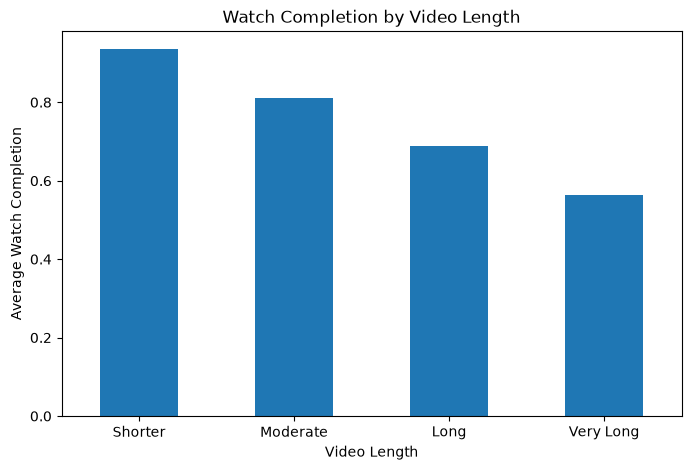

In [64]:
# Visualize watch completion by video length
duration_analysis.plot(
    x="duration_group",
    y="avg_watch_percent",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.ylabel("Average Watch Completion")
plt.xlabel("Video Length")
plt.title("Watch Completion by Video Length")
plt.xticks(rotation=0)
plt.show()

In [65]:
# Compare engagement rates by video length
duration_analysis[[
    "duration_group",
    "like_rate",
    "comment_rate"
]]

,duration_group,like_rate,comment_rate
0,Shorter,0.301192,0.099323
1,Moderate,0.300844,0.099062
2,Long,0.300611,0.099498
3,Very Long,0.300235,0.100106


In [68]:
# Export cleaned dataset for Tableau
df.to_csv(
    r"C:\Users\asgaj\Downloads\youtube_cleaned.csv",
    index=False
)

print("Cleaned dataset exported successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset exported successfully.
Rows: 1000000
Columns: 16
